# Exploring the image dataset

This notebook explores the images before we build transformations or a model. The goal is to understand the data and look for class imbalance, unusual dimensions, or images that may need attention.

Place the real images in `data/train/` and `data/validation/` using the class-directory layout documented in the project README before running the notebook.

In [2]:
from collections import Counter
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from PIL import Image

# Make the notebook work when JupyterLab is started from either the project
# root or the notebooks directory.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.dataset import load_datasets, print_dataset_summary

TRAIN_DIR = PROJECT_ROOT / "data" / "train"
VALIDATION_DIR = PROJECT_ROOT / "data" / "validation"

## 1. Load the datasets

`ImageFolder` reads the class names from the subdirectory names and returns image/label pairs. At this stage we keep images as PIL images so that we can inspect their original dimensions before adding transformations.

In [4]:
train_dataset, validation_dataset = load_datasets(
    train_dir=TRAIN_DIR,
    validation_dir=VALIDATION_DIR,
)

print_dataset_summary(train_dataset, validation_dataset)

Number of training images: 45
Number of validation images: 15
Class names: ['bottle', 'pencil', 'wristwatch']
Class-to-index mapping: {'bottle': 0, 'pencil': 1, 'wristwatch': 2}


## 2. Display several training images

Viewing examples is a simple but important check. It can reveal incorrect labels, corrupted files, unexpected backgrounds, or visual differences between classes that a numeric summary would miss.

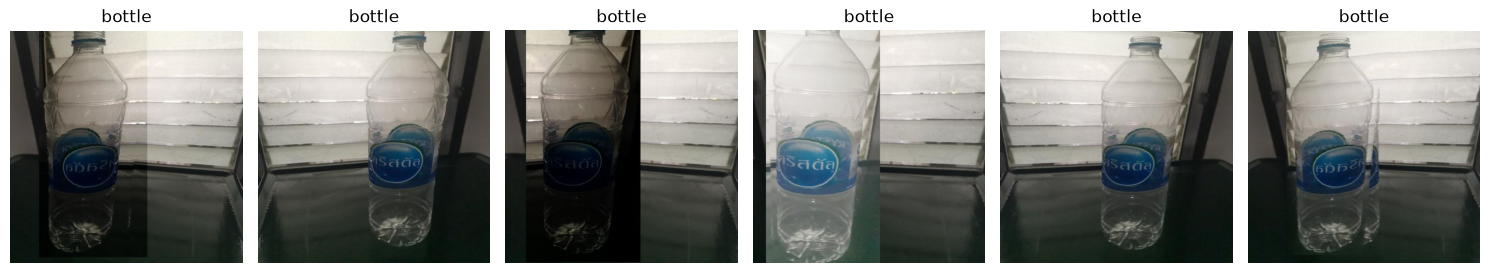

In [5]:
number_to_display = min(6, len(train_dataset.samples))
fig, axes = plt.subplots(1, number_to_display, figsize=(15, 3))
if number_to_display == 1:
    axes = [axes]

for axis, (image_path, label_index) in zip(axes, train_dataset.samples[:number_to_display]):
    with Image.open(image_path) as image:
        axis.imshow(image.convert("RGB"))
    axis.set_title(train_dataset.classes[label_index])
    axis.axis("off")

plt.tight_layout()
plt.show()

## 3. Display one example from each class

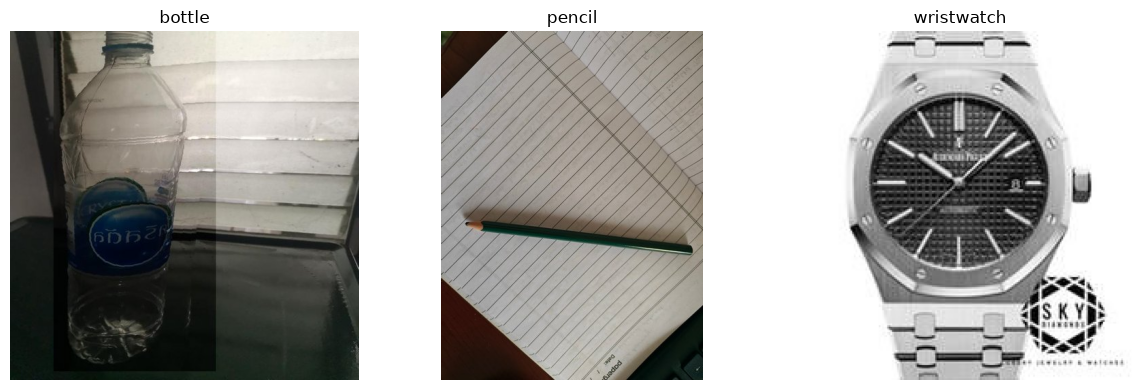

In [6]:
examples_by_class = {}
for class_index, class_name in enumerate(train_dataset.classes):
    examples_by_class[class_name] = next(
        image_path
        for image_path, label_index in train_dataset.samples
        if label_index == class_index
    )

fig, axes = plt.subplots(1, len(examples_by_class), figsize=(12, 4))
for axis, (class_name, image_path) in zip(axes, examples_by_class.items()):
    with Image.open(image_path) as image:
        axis.imshow(image.convert("RGB"))
    axis.set_title(class_name)
    axis.axis("off")

plt.tight_layout()
plt.show()

## 4. Inspect image dimensions

Images may have different widths, heights, and aspect ratios. We inspect the original `(width, height)` values before deciding how to resize or crop them.

In [7]:
train_dimensions = []
for image_path, _ in train_dataset.samples:
    with Image.open(image_path) as image:
        train_dimensions.append(image.size)

dimension_counts = Counter(train_dimensions)
print("Unique training image dimensions:")
for dimensions, count in dimension_counts.most_common():
    print(f"  {dimensions}: {count} image(s)")

print(f"Smallest width: {min(width for width, _ in train_dimensions)}")
print(f"Largest width: {max(width for width, _ in train_dimensions)}")
print(f"Smallest height: {min(height for _, height in train_dimensions)}")
print(f"Largest height: {max(height for _, height in train_dimensions)}")

Unique training image dimensions:
  (512, 512): 15 image(s)
  (210, 210): 15 image(s)
  (384, 512): 11 image(s)
  (512, 384): 2 image(s)
  (256, 256): 2 image(s)
Smallest width: 210
Largest width: 512
Smallest height: 210
Largest height: 512


### Why dimensions need to be normalized

A neural network processes a batch as one tensor. Images in the same batch therefore need compatible height and width, such as `224 x 224`; otherwise they cannot be stacked into a single tensor. Later, the transformation step will resize and crop images to a consistent spatial shape. This is different from pixel-value normalization: resizing standardizes spatial dimensions, while pixel normalization changes the numerical range and distribution of color values.

## 5. Count images in each class

In [8]:
train_counts = Counter(label_index for _, label_index in train_dataset.samples)
validation_counts = Counter(label_index for _, label_index in validation_dataset.samples)

print("Training images per class:")
for class_index, class_name in enumerate(train_dataset.classes):
    print(f"  {class_name}: {train_counts[class_index]}")

print("Validation images per class:")
for class_index, class_name in enumerate(validation_dataset.classes):
    print(f"  {class_name}: {validation_counts[class_index]}")

Training images per class:
  bottle: 15
  pencil: 15
  wristwatch: 15
Validation images per class:
  bottle: 5
  pencil: 5
  wristwatch: 5


## 6. Plot the class distribution

A balanced dataset has a similar number of examples per class. If one class dominates, accuracy may look good even when the model performs poorly on less common classes, so this distribution is useful context for later evaluation metrics.

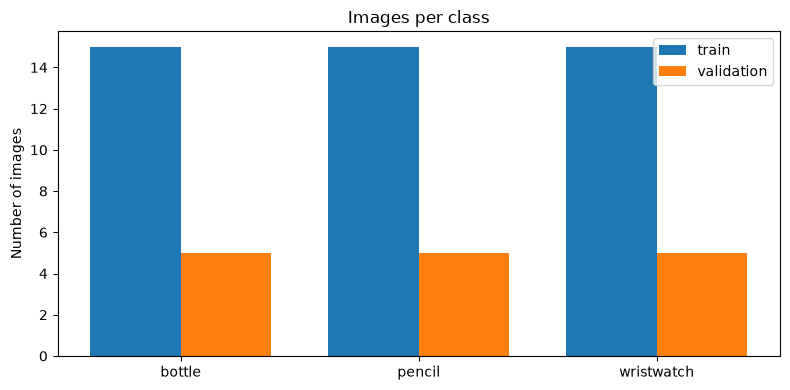

In [9]:
class_names = train_dataset.classes
train_values = [train_counts[index] for index in range(len(class_names))]
validation_values = [validation_counts[index] for index in range(len(class_names))]

positions = list(range(len(class_names)))
bar_width = 0.38
fig, axis = plt.subplots(figsize=(8, 4))
axis.bar([position - bar_width / 2 for position in positions], train_values, bar_width, label="train")
axis.bar([position + bar_width / 2 for position in positions], validation_values, bar_width, label="validation")
axis.set_xticks(positions, class_names)
axis.set_ylabel("Number of images")
axis.set_title("Images per class")
axis.legend()
plt.tight_layout()
plt.show()

## 7. Visualize validation predictions

This section compares the model's prediction with the actual class and shows its confidence. Correct predictions help us see what the model recognizes; incorrect predictions reveal failure modes such as visually similar objects, distracting backgrounds, or mislabeled images. A high-confidence mistake is especially useful to investigate because it may indicate a systematic problem.

Run the training step first so that `models/best_model.pth` exists. Before a checkpoint is available, the code below reports that this section is waiting for one.

In [10]:
import torch

from src.device import select_device
from src.model import create_model
from src.transforms import create_validation_transform

CHECKPOINT_PATH = PROJECT_ROOT / "models" / "best_model.pth"

if not CHECKPOINT_PATH.exists():
    print(f"Checkpoint not found: {CHECKPOINT_PATH}")
    print("Train the model before visualizing predictions.")
else:
    checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu")
    if checkpoint["class_to_idx"] != validation_dataset.class_to_idx:
        raise ValueError("Checkpoint and validation class mappings do not match.")

    prediction_model = create_model(pretrained=False)
    prediction_model.load_state_dict(checkpoint["model_state_dict"])
    prediction_device = select_device()
    prediction_model.to(prediction_device)
    prediction_model.eval()
    validation_transform = create_validation_transform()
    prediction_records = []

    with torch.no_grad():
        for image_path, actual_index in validation_dataset.samples:
            with Image.open(image_path) as image:
                display_image = image.convert("RGB").copy()
            image_tensor = validation_transform(display_image).unsqueeze(0)
            logits = prediction_model(image_tensor.to(prediction_device))
            probabilities = torch.softmax(logits, dim=1)[0]
            predicted_index = int(probabilities.argmax())
            prediction_records.append({
                "image": display_image,
                "actual": validation_dataset.classes[actual_index],
                "predicted": validation_dataset.classes[predicted_index],
                "confidence": float(probabilities[predicted_index].cpu()),
                "correct": predicted_index == actual_index,
            })

    correct_records = [record for record in prediction_records if record["correct"]]
    incorrect_records = [record for record in prediction_records if not record["correct"]]
    print(f"Correct predictions: {len(correct_records)}")
    print(f"Incorrect predictions: {len(incorrect_records)}")
    if not correct_records or not incorrect_records:
        print("The current checkpoint does not contain both prediction types to display.")

    columns = max(1, min(4, max(len(correct_records), len(incorrect_records))))
    figure, axes = plt.subplots(2, columns, figsize=(4 * columns, 8), squeeze=False)
    groups = [("Correct", correct_records), ("Incorrect", incorrect_records)]
    for row, (group_name, records) in enumerate(groups):
        for column in range(columns):
            axis = axes[row][column]
            axis.axis("off")
            if column >= len(records):
                continue
            record = records[column]
            axis.imshow(record["image"])
            axis.set_title(
                f"{group_name}\n"
                f"actual: {record['actual']}\n"
                f"predicted: {record['predicted']}\n"
                f"confidence: {record['confidence']:.2%}"
            )
    figure.tight_layout()
    plt.show()

Checkpoint not found: /home/ubuntu/projects/image-classifier/models/best_model.pth
Train the model before visualizing predictions.
